# KOA — Custom CNN (from scratch) — Mercy
**Controlled method** — identical to the ResNet, ViT and DenseNet notebooks in
every respect except the model, so the four-way comparison stays fair.

Design: 80% train / 20% test, **no validation**, ImageNet normalization, robust
16-bit TIFF loader, train-only augmentation, Grade-4 oversampling, fixed 30
epochs, final model tested on the frozen test set. Loops all six batches and
writes results to `MyDrive/KOA/runs/cnn/` (read by the combiner notebook).

### How to run
1. **Runtime → Change runtime type → GPU.**
2. Run every cell top to bottom.

Your data lives in `Koa Project/Data/Dataset/` (batch_500 … batch_4686), each
with `train/` and `test/` Grade-0..4 subfolders. The notebook copies each batch
to fast local disk once before training (Colab reads local files far faster than
Drive).


In [1]:
import torch, torchvision, sys
print("python:", sys.version.split()[0], "| torch:", torch.__version__)
print("GPU   :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE (set Runtime -> GPU!)")


python: 3.13.15 | torch: 2.11.0+cu130
GPU   : Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# ============================================================
# CONFIG
# ============================================================
MEMBER      = "Mercy"
MODEL_NAME  = "cnn"          # folder name the combiner expects

# Your extracted batch folders. (Auto-corrected below if the path is slightly off.)
DRIVE_DATA  = "/content/drive/MyDrive/Koa Project/Data/Dataset"
DRIVE_OUT   = "/content/drive/MyDrive/KOA/runs"   # results -> runs/cnn/
LOCAL_ROOT  = "/content/koa"                       # fast local disk

BATCHES     = [500, 1000, 1500, 2000, 3000, 4686]
EPOCHS      = 30
BATCH_SIZE  = 32
LR          = 1e-3           # higher LR for the from-scratch CNN
NUM_WORKERS = 0              # 0 keeps Colab logs clean (no worker-shutdown noise)
SAVE_CHECKPOINTS = True       # CNN checkpoints are tiny

# ---- SHARED POLICY (identical for all four members) ----
IMAGE_SIZE, NUM_CLASSES, SEED = 224, 5, 42
MEAN = [0.485, 0.456, 0.406]     # ImageNet
STD  = [0.229, 0.224, 0.225]


In [ ]:
# ============================================================
# LOCATE the folder that holds batch_500 .. batch_4686
# (uses batch_4686/train as the anchor so it can only match the
#  folder that actually contains all six batches)
# ============================================================
import os, glob
def find_data_root():
    if os.path.isdir(os.path.join(DRIVE_DATA, "batch_4686", "train")):
        return DRIVE_DATA
    hits = glob.glob("/content/drive/MyDrive/**/batch_4686/train", recursive=True)
    if hits:
        return os.path.dirname(os.path.dirname(hits[0]))
    raise FileNotFoundError("Could not find batch_4686/train anywhere under MyDrive. "
                            "Check that Drive is mounted and the folder is fully synced.")

DATA_ROOT = find_data_root()
print("DATA_ROOT =", DATA_ROOT)
for b in [500,1000,1500,2000,3000,4686]:
    ok = os.path.isdir(os.path.join(DATA_ROOT, f"batch_{b}", "train"))
    print(f"  batch_{b}: {'OK' if ok else 'MISSING'}")


DATA_ROOT = /content/drive/MyDrive/Koa Project/Data/Dataset
  batch_500: OK
  batch_1000: OK
  batch_1500: OK
  batch_2000: OK
  batch_3000: OK
  batch_4686: OK


In [ ]:
# ============================================================
# SHARED POLICY: seed, robust loader, transforms, sampler, metrics
# (IDENTICAL for all four members)
# ============================================================
import json, shutil, random
import numpy as np
from PIL import Image
import torch, torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             cohen_kappa_score, confusion_matrix)

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Robust loader: correct for 8-bit AND 16-bit TIFF (per-image min-max -> 8-bit RGB).
def load_xray(path):
    arr = np.asarray(Image.open(path)).astype(np.float32)
    if arr.ndim == 3:
        arr = arr[..., 0]
    mn, mx = float(arr.min()), float(arr.max())
    arr = (arr - mn) / (mx - mn + 1e-6)
    return Image.fromarray((arr * 255).astype(np.uint8)).convert("RGB")

def train_transform():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomAffine(degrees=7, translate=(0.03,0.03), scale=(0.95,1.05)),
        transforms.ColorJitter(brightness=0.10, contrast=0.10),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

def eval_transform():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

def make_weighted_sampler(labels):
    labels = np.asarray(labels)
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    w = (1.0/np.maximum(counts,1))[labels]
    return WeightedRandomSampler(torch.DoubleTensor(w), len(w), replacement=True)

def compute_metrics(yt, yp):
    wp,wr,wf,_ = precision_recall_fscore_support(yt,yp,average="weighted",zero_division=0)
    mp,mr,mf,_ = precision_recall_fscore_support(yt,yp,average="macro",zero_division=0)
    return {"accuracy":float(accuracy_score(yt,yp)),
            "weighted_precision":float(wp),"weighted_recall":float(wr),"weighted_f1":float(wf),
            "macro_precision":float(mp),"macro_recall":float(mr),"macro_f1":float(mf),
            "cohen_kappa":float(cohen_kappa_score(yt,yp)),
            "quadratic_weighted_kappa":float(cohen_kappa_score(yt,yp,weights="quadratic"))}


In [ ]:
# ============================================================
# MODEL: Custom CNN (from scratch)
# ============================================================
class SimpleCNN(nn.Module):
    def __init__(self, n):
        super().__init__()
        def blk(i,o): return nn.Sequential(nn.Conv2d(i,o,3,padding=1),
            nn.BatchNorm2d(o), nn.ReLU(True), nn.MaxPool2d(2))
        self.features = nn.Sequential(blk(3,32), blk(32,64), blk(64,128),
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256),
            nn.ReLU(True), nn.AdaptiveAvgPool2d(1))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.4), nn.Linear(256, n))
    def forward(self,x): return self.classifier(self.features(x))

def build_model(n=NUM_CLASSES):
    return SimpleCNN(n)


In [ ]:
# ============================================================
# COPY each batch to local disk (once) + TRAIN + FROZEN-TEST EVAL
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def prepare_local(batch):
    src = os.path.join(DATA_ROOT, f"batch_{batch}")
    if not os.path.isdir(os.path.join(src, "train")): return None
    dst = os.path.join(LOCAL_ROOT, f"batch_{batch}")
    if not os.path.isdir(os.path.join(dst, "train")):
        print(f"  copying batch_{batch} to local disk (one-time, may take a few min)...")
        shutil.copytree(src, dst, dirs_exist_ok=True)
    return dst

def train_one_epoch(model, loader, crit, opt):
    model.train(); tot=0.0; correct=0; n=0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad(); out = model(x); loss = crit(out, y)
        loss.backward(); opt.step()
        tot += loss.item()*x.size(0); correct += (out.argmax(1)==y).sum().item(); n += x.size(0)
    return tot/n, correct/n

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); ys, ps = [], []
    for x,y in loader:
        out = model(x.to(device))
        ps.extend(out.argmax(1).cpu().numpy()); ys.extend(y.numpy())
    return np.array(ys), np.array(ps)

def run_batch(batch):
    set_seed(SEED)
    root = prepare_local(batch)
    if root is None:
        print(f"  batch_{batch}: folder not found -> skipped"); return None

    tr = ImageFolder(os.path.join(root,"train"), loader=load_xray, transform=train_transform())
    te = ImageFolder(os.path.join(root,"test"),  loader=load_xray, transform=eval_transform())
    lk = dict(num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))
    tl = DataLoader(tr, batch_size=BATCH_SIZE,
                    sampler=make_weighted_sampler([l for _,l in tr.samples]), **lk)
    el = DataLoader(te, batch_size=BATCH_SIZE, shuffle=False, **lk)

    model = build_model().to(device)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    for ep in range(1, EPOCHS+1):
        loss, acc = train_one_epoch(model, tl, crit, opt); sched.step()
        print(f"  batch_{batch} ep{ep:02d} | train_loss {loss:.3f} | train_acc {acc:.3f}")

    yt, yp = evaluate(model, el)                 # FROZEN TEST
    res = compute_metrics(yt, yp); res.update({"model":MODEL_NAME, "batch":batch})

    outdir = os.path.join(DRIVE_OUT, MODEL_NAME); os.makedirs(outdir, exist_ok=True)
    json.dump(res, open(os.path.join(outdir, f"batch_{batch}_metrics.json"),"w"), indent=2)
    np.savetxt(os.path.join(outdir, f"batch_{batch}_confusion.csv"),
               confusion_matrix(yt, yp, labels=list(range(NUM_CLASSES))), fmt="%d", delimiter=",")
    if SAVE_CHECKPOINTS:
        torch.save(model.state_dict(), os.path.join(outdir, f"batch_{batch}_final.pth"))

    shutil.rmtree(root, ignore_errors=True)      # free local disk before next batch
    print(f"  -> TEST acc {res['accuracy']:.3f} | macroF1 {res['macro_f1']:.3f} "
          f"| QWK {res['quadratic_weighted_kappa']:.3f}")
    return res


In [ ]:
# ============================================================
# RUN ALL SIX BATCHES
# ============================================================
all_results = []
for b in BATCHES:
    print(f"\n===== cnn  batch_{b} =====")
    r = run_batch(b)
    if r is not None: all_results.append(r)
print("\nDone.")



===== cnn  batch_500 =====
  copying batch_500 to local disk (one-time, may take a few min)...
  batch_500 ep01 | train_loss 1.571 | train_acc 0.312
  batch_500 ep02 | train_loss 1.553 | train_acc 0.314
  batch_500 ep03 | train_loss 1.580 | train_acc 0.249
  batch_500 ep04 | train_loss 1.552 | train_acc 0.293
  batch_500 ep05 | train_loss 1.532 | train_acc 0.306
  batch_500 ep06 | train_loss 1.530 | train_acc 0.296
  batch_500 ep07 | train_loss 1.530 | train_acc 0.312
  batch_500 ep08 | train_loss 1.479 | train_acc 0.327
  batch_500 ep09 | train_loss 1.513 | train_acc 0.306
  batch_500 ep10 | train_loss 1.510 | train_acc 0.343
  batch_500 ep11 | train_loss 1.511 | train_acc 0.332
  batch_500 ep12 | train_loss 1.502 | train_acc 0.317
  batch_500 ep13 | train_loss 1.428 | train_acc 0.382
  batch_500 ep14 | train_loss 1.456 | train_acc 0.330
  batch_500 ep15 | train_loss 1.389 | train_acc 0.385
  batch_500 ep16 | train_loss 1.353 | train_acc 0.427
  batch_500 ep17 | train_loss 1.407 | tr

 batch  accuracy  macro_f1  weighted_f1  quadratic_weighted_kappa
   500  0.294995  0.302233     0.334266                  0.522097
  1000  0.569755  0.415691     0.571461                  0.662520
  1500  0.597444  0.443269     0.595903                  0.695591
  2000  0.595314  0.451321     0.591042                  0.690778
  3000  0.613419  0.468065     0.600666                  0.695817
  4686  0.597444  0.478711     0.604717                  0.715409


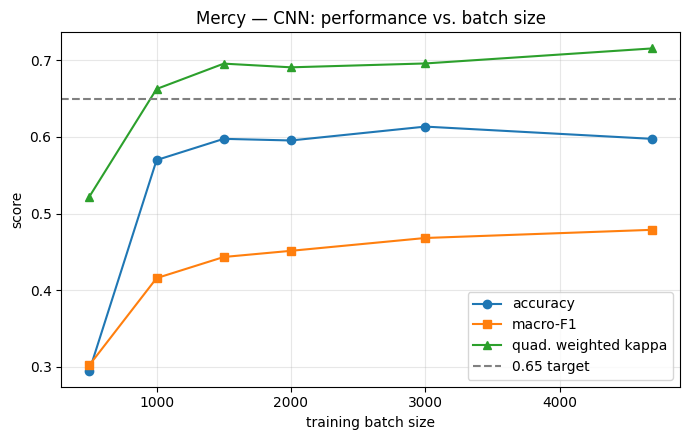

In [ ]:
# ============================================================
# COMPARISON ACROSS BATCH SIZES (CNN)
# ============================================================
import pandas as pd, matplotlib.pyplot as plt
df = pd.DataFrame(all_results)[
    ["batch","accuracy","macro_f1","weighted_f1","quadratic_weighted_kappa"]].sort_values("batch")
df.to_csv(os.path.join(DRIVE_OUT, MODEL_NAME, "summary.csv"), index=False)
print(df.to_string(index=False))

plt.figure(figsize=(7,4.5))
plt.plot(df.batch, df.accuracy, "o-", label="accuracy")
plt.plot(df.batch, df.macro_f1, "s-", label="macro-F1")
plt.plot(df.batch, df.quadratic_weighted_kappa, "^-", label="quad. weighted kappa")
plt.axhline(0.65, ls="--", color="grey", label="0.65 target")
plt.xlabel("training batch size"); plt.ylabel("score")
plt.title("Mercy — CNN: performance vs. batch size")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT, MODEL_NAME, "summary.png"), dpi=120)
plt.show()


In [ ]:
import os, json, glob

outdir = os.path.join(DRIVE_OUT, MODEL_NAME)   # .../KOA/runs/cnn
files = sorted(glob.glob(os.path.join(outdir, "batch_*_metrics.json")),
               key=lambda p: int(p.split("batch_")[1].split("_")[0]))

print(f"{'batch':>7} | {'accuracy':>9} | {'macro_f1':>8} | {'QWK':>6}")
print("-" * 40)
for f in files:
    m = json.load(open(f))
    print(f"{m['batch']:>7} | {m['accuracy']:>9.3f} | {m['macro_f1']:>8.3f} | {m['quadratic_weighted_kappa']:>6.3f}")

  batch |  accuracy | macro_f1 |    QWK
----------------------------------------
    500 |     0.295 |    0.302 |  0.522
   1000 |     0.570 |    0.416 |  0.663
   1500 |     0.597 |    0.443 |  0.696
   2000 |     0.595 |    0.451 |  0.691
   3000 |     0.613 |    0.468 |  0.696
   4686 |     0.597 |    0.479 |  0.715


In [ ]:
import os, json, glob

outdir = os.path.join(DRIVE_OUT, MODEL_NAME)   # .../KOA/runs/cnn
files = sorted(glob.glob(os.path.join(outdir, "batch_*_metrics.json")),
               key=lambda p: int(p.split("batch_")[1].split("_")[0]))

for f in files:
    m = json.load(open(f))
    print(f"batch_{m['batch']}: accuracy = {m['accuracy']*100:.2f}%")

batch_500: accuracy = 29.50%
batch_1000: accuracy = 56.98%
batch_1500: accuracy = 59.74%
batch_2000: accuracy = 59.53%
batch_3000: accuracy = 61.34%
batch_4686: accuracy = 59.74%


In [ ]:
# ============================================================
# ACCURACY-FOCUSED OVERRIDES  (run this, then re-run "RUN ALL BATCHES")
# ============================================================
SAMPLER_POWER = 0.5   # 0.0 = no oversampling (max accuracy) ... 1.0 = full balance
EPOCHS        = 45    # from-scratch CNNs benefit from more epochs

# Softer class sampler: power=0.5 (sqrt) instead of full inverse-frequency
def make_weighted_sampler(labels, power=SAMPLER_POWER):
    labels = np.asarray(labels)
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    w = ((1.0 / np.maximum(counts, 1)) ** power)[labels]
    return WeightedRandomSampler(torch.DoubleTensor(w), len(w), replacement=True)

# Deeper CNN: double-conv blocks + wider classifier (more capacity, same input)
class ImprovedCNN(nn.Module):
    def __init__(self, n):
        super().__init__()
        def blk(i, o):
            return nn.Sequential(
                nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(True),
                nn.Conv2d(o, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(True),
                nn.MaxPool2d(2))
        self.features = nn.Sequential(
            blk(3, 32), blk(32, 64), blk(64, 128), blk(128, 256),
            nn.AdaptiveAvgPool2d(1))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.5), nn.Linear(256, 128),
            nn.ReLU(True), nn.Dropout(0.3), nn.Linear(128, n))
    def forward(self, x): return self.classifier(self.features(x))

def build_model(n=NUM_CLASSES):
    return ImprovedCNN(n)

print(f"Overrides set: SAMPLER_POWER={SAMPLER_POWER}, EPOCHS={EPOCHS}, deeper CNN")

Overrides set: SAMPLER_POWER=0.5, EPOCHS=45, deeper CNN


### Notes
- **Controlled version** — same loader, transforms, normalization, sampler,
  epochs, batch size, schedule and frozen test as the other three members. Only
  the model (and the CNN's 1e-3 LR) differs.
- **No validation by design.** Fixed 30 epochs, final model tested.
- Results land in `MyDrive/KOA/runs/cnn/`. For the combiner, gather all four
  members' `runs/<model>/` folders into one shared location.
